# Baseline MedGemma Evaluation — No QLoRA — Kaggle P100 Version v11 — FULL DATASET, FP32-stable scoring

This notebook evaluates the **base MedGemma model without QLoRA adapters or fine-tuning** on colorectal histology image classification.

Kaggle setup checklist:

1. In **Notebook settings**, set **Accelerator** to **GPU P100**.
2. Turn **Internet** on, unless you have already added the model/dataset as Kaggle inputs.
3. Add a Kaggle secret named `HF_TOKEN` with a Hugging Face token that has access to `google/medgemma-1.5-4b-it`.
4. Accept the MedGemma model license/access request on Hugging Face before running this notebook.
5. Run the dependency cell first. It installs a P100-compatible PyTorch/NumPy/Transformers stack and intentionally restarts the kernel once. After the restart, run the notebook from the top again.

v11 fix: the previous forced-choice run produced `nan` class scores and therefore selected the first label (`ADI`) for every sample. This version uses fp32 compute for the 4-bit model on P100, checks for non-finite logits, writes to a fresh `results_v11_fp32` folder, and stops at the smoke test if all predictions collapse to one label.

v10 changes: runs the full evaluation set by default (`MAX_EVAL_SAMPLES = None`) and checkpoints predictions every 50 samples so progress is not lost during long Kaggle/P100 runs.

Outputs are written to `/kaggle/working/MedGemma_Baseline_No_QLoRA_Eval/results_v11_fp32`, which will appear in the Kaggle notebook **Output** panel after the run.


## 1. Install dependencies


In [1]:
# Run this cell first.
# Kaggle's default PyTorch wheel can be compiled for newer GPUs only, which breaks on Tesla P100 (sm_60).
# This bootstrap cell is intentionally restart-safe:
#   - It never lets Hugging Face/quantization installs upgrade torch behind our back.
#   - It installs the P100-compatible PyTorch wheel LAST.
#   - It then hard-restarts Python, because imported binary packages cannot be safely swapped in-place.
#   - On the next run, it verifies that the active torch build contains sm_60 kernels.

import os
import sys
import subprocess
from pathlib import Path

MARKER = Path('/kaggle/working/.medgemma_p100_deps_v6_installed')
OLD_MARKERS = [
    Path('/kaggle/working/.medgemma_p100_deps_v2_installed'),
    Path('/kaggle/working/.medgemma_p100_deps_v3_installed'),
    Path('/kaggle/working/.medgemma_p100_deps_v4_installed'),
    Path('/kaggle/working/.medgemma_p100_deps_v5_installed'),
]
CORE_MODULES = ('torch', 'numpy', 'pandas', 'scipy', 'sklearn')


def pip_install(args):
    cmd = [sys.executable, '-m', 'pip', 'install', '-q', '--no-cache-dir'] + list(args)
    print('+ ' + ' '.join(cmd), flush=True)
    subprocess.check_call(cmd)


def pip_uninstall(packages):
    cmd = [sys.executable, '-m', 'pip', 'uninstall', '-y', '-q'] + list(packages)
    print('+ ' + ' '.join(cmd), flush=True)
    subprocess.call(cmd)


def install_stack_and_restart(reason):
    already_loaded = [module for module in CORE_MODULES if module in sys.modules]
    print(reason, flush=True)
    if already_loaded:
        print('Already loaded in this kernel:', ', '.join(already_loaded), flush=True)
        print('That is okay. Installing now, then restarting so Python loads the repaired packages.', flush=True)

    for old_marker in OLD_MARKERS:
        try:
            old_marker.unlink()
        except FileNotFoundError:
            pass

    # Remove packages that have repeatedly caused Kaggle/P100 resolver loops in this notebook.
    # In v5, accelerate/bitsandbytes reinstall pulled torch 2.11 back in after torch 2.5.1 was installed.
    pip_uninstall(['torch', 'torchvision', 'torchaudio', 'accelerate', 'bitsandbytes'])

    # General Python/data stack. Keep NumPy <2 because some Kaggle scientific wheels still expect it.
    # These installs are intentionally separated from torch.
    pip_install([
        '--force-reinstall',
        'numpy==1.26.4',
        'pandas==2.2.2',
        'matplotlib==3.8.4',
        'pillow==11.3.0',
    ])

    # Hugging Face stack. Do NOT include accelerate/bitsandbytes here, because their dependency
    # metadata can cause pip to reinstall a newer torch that lacks sm_60 on Kaggle P100.
    pip_install([
        '--force-reinstall',
        'transformers==4.52.3',
        'datasets',
        'huggingface_hub',
        'tokenizers>=0.21,<0.22',
        'safetensors>=0.4.5',
        'requests',
        'regex',
        'tqdm',
        'pyyaml',
        'packaging',
        'filelock',
    ])

    # Install these without dependencies so they cannot upgrade torch.
    pip_install([
        '--force-reinstall',
        '--no-deps',
        'accelerate>=0.34.0,<1.10.0',
        'bitsandbytes>=0.45.0,<0.47.0',
    ])

    # Re-repair NumPy/pandas after datasets/transformers, because datasets may pull newer NumPy/pandas.
    pip_install([
        '--force-reinstall',
        'numpy==1.26.4',
        'pandas==2.2.2',
        'matplotlib==3.8.4',
        'pillow==11.3.0',
    ])

    # CRITICAL: install P100-compatible PyTorch LAST so no later pip step can replace it.
    # This is the CUDA 12.1 PyTorch build used for Tesla P100/sm_60 compatibility.
    pip_install([
        '--force-reinstall',
        'torch==2.5.1',
        'torchvision==0.20.1',
        'torchaudio==2.5.1',
        '--index-url',
        'https://download.pytorch.org/whl/cu121',
    ])

    MARKER.write_text('installed\n')
    print('\nDependency repair complete. Restarting the kernel now.', flush=True)
    print('After Kaggle restarts, run the notebook from the top again. This cell should print torch 2.5.1 and an arch list containing sm_60.', flush=True)
    sys.stdout.flush()
    os._exit(0)


if not MARKER.exists():
    install_stack_and_restart('No v6 dependency marker found. Installing the Kaggle/P100-compatible stack.')

# Marker exists. Validate the *active* runtime, not just the marker.
try:
    import torch
    import numpy as np
    import pandas as pd
    import matplotlib
    import transformers
except Exception as exc:
    try:
        MARKER.unlink()
    except FileNotFoundError:
        pass
    install_stack_and_restart(f'Dependency marker exists, but imports failed: {exc!r}. Reinstalling.')

print('Dependency marker found. Validating active runtime...', flush=True)
print('Torch:', torch.__version__, flush=True)
print('Torch CUDA runtime:', torch.version.cuda, flush=True)
print('Torch CUDA arch list:', torch.cuda.get_arch_list() if torch.cuda.is_available() else 'CUDA unavailable', flush=True)
print('NumPy:', np.__version__, flush=True)
print('pandas:', pd.__version__, flush=True)
print('matplotlib:', matplotlib.__version__, flush=True)
print('transformers:', transformers.__version__, flush=True)

if torch.cuda.is_available():
    capability = torch.cuda.get_device_capability(0)
    print('GPU:', torch.cuda.get_device_name(0), flush=True)
    print('GPU compute capability:', capability, flush=True)
    if capability == (6, 0) and 'sm_60' not in torch.cuda.get_arch_list():
        try:
            MARKER.unlink()
        except FileNotFoundError:
            pass
        install_stack_and_restart('Active torch still lacks sm_60 support for Tesla P100. Reinstalling with torch as the final install step.')

from packaging.version import Version
if Version(transformers.__version__) >= Version('4.55.0') and Version(torch.__version__.split('+')[0]) < Version('2.6.0'):
    try:
        MARKER.unlink()
    except FileNotFoundError:
        pass
    install_stack_and_restart('Transformers is too new for torch<2.6 with Gemma-3 masking. Reinstalling pinned Transformers 4.52.3.')

if Version(torch.__version__.split('+')[0]) != Version('2.5.1'):
    try:
        MARKER.unlink()
    except FileNotFoundError:
        pass
    install_stack_and_restart('Active torch is not 2.5.1 after restart. Reinstalling with torch as the final install step.')

print('Dependency check passed. Continue to the next cell.', flush=True)


Dependency marker found. Validating active runtime...
Torch: 2.5.1+cu121
Torch CUDA runtime: 12.1
Torch CUDA arch list: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
NumPy: 2.4.3
pandas: 2.2.2
matplotlib: 3.8.4
transformers: 4.52.3
GPU: Tesla P100-PCIE-16GB
GPU compute capability: (6, 0)
Dependency check passed. Continue to the next cell.


## 2. Imports and Kaggle/P100 setup


In [2]:
import os
import re
import json
import string
import zipfile
import urllib.request
from pathlib import Path

# Set before heavy imports/allocation.
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'max_split_size_mb:128')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from huggingface_hub import login
from datasets import load_dataset
from transformers import AutoProcessor, Gemma3ForConditionalGeneration, BitsAndBytesConfig


def simple_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(y_true == y_pred)) if len(y_true) else 0.0


def simple_confusion_matrix(y_true, y_pred, labels):
    label_to_pos = {label: idx for idx, label in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=int)
    for true_label, pred_label in zip(y_true, y_pred):
        if true_label in label_to_pos and pred_label in label_to_pos:
            cm[label_to_pos[true_label], label_to_pos[pred_label]] += 1
    return cm


def per_class_report(y_true, y_pred, labels, target_names):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    rows = {}
    supports = []
    f1s = []
    precisions = []
    recalls = []

    for label, name in zip(labels, target_names):
        tp = int(np.sum((y_true == label) & (y_pred == label)))
        fp = int(np.sum((y_true != label) & (y_pred == label)))
        fn = int(np.sum((y_true == label) & (y_pred != label)))
        support = int(np.sum(y_true == label))

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

        rows[name] = {
            'precision': precision,
            'recall': recall,
            'f1-score': f1,
            'support': support,
        }
        supports.append(support)
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)

    total_support = int(np.sum(supports))
    accuracy = simple_accuracy(y_true, y_pred)
    weights = np.asarray(supports, dtype=float)

    rows['accuracy'] = {
        'precision': accuracy,
        'recall': accuracy,
        'f1-score': accuracy,
        'support': total_support,
    }
    rows['macro avg'] = {
        'precision': float(np.mean(precisions)) if precisions else 0.0,
        'recall': float(np.mean(recalls)) if recalls else 0.0,
        'f1-score': float(np.mean(f1s)) if f1s else 0.0,
        'support': total_support,
    }
    if total_support:
        rows['weighted avg'] = {
            'precision': float(np.average(precisions, weights=weights)),
            'recall': float(np.average(recalls, weights=weights)),
            'f1-score': float(np.average(f1s, weights=weights)),
            'support': total_support,
        }
    else:
        rows['weighted avg'] = {
            'precision': 0.0,
            'recall': 0.0,
            'f1-score': 0.0,
            'support': 0,
        }

    return rows


def simple_f1(y_true, y_pred, labels, average='macro'):
    report = per_class_report(y_true, y_pred, labels, [str(x) for x in labels])
    if average == 'macro':
        return float(report['macro avg']['f1-score'])
    if average == 'weighted':
        return float(report['weighted avg']['f1-score'])
    raise ValueError("average must be 'macro' or 'weighted'")


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print('Torch:', torch.__version__)
print('Torch CUDA runtime:', torch.version.cuda)
print('Torch CUDA arch list:', torch.cuda.get_arch_list())

if not torch.cuda.is_available():
    raise RuntimeError('No GPU detected. In Kaggle, open Notebook settings and set Accelerator to GPU P100.')

device = 'cuda'
GPU_NAME = torch.cuda.get_device_name(0)
GPU_CAPABILITY = torch.cuda.get_device_capability(0)

print('Device:', device)
print('GPU:', GPU_NAME)
print('GPU compute capability:', GPU_CAPABILITY)

# Tesla P100 is compute capability 6.0. The active torch wheel must include sm_60 kernels.
if GPU_CAPABILITY == (6, 0) and 'sm_60' not in torch.cuda.get_arch_list():
    raise RuntimeError(
        'This PyTorch build does not include sm_60 kernels for Tesla P100. '
        'Restart the Kaggle session, rerun the dependency cell, then rerun this cell.'
    )

# P100 does not support TF32 or BF16 acceleration. Keep computations in fp16/fp32.
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

WORKING_DIR = Path('/kaggle/working')
PROJECT_DIR = WORKING_DIR / 'MedGemma_Baseline_No_QLoRA_Eval'
RESULTS_DIR = PROJECT_DIR / 'results_v11_fp32'
DATA_DIR = PROJECT_DIR / 'data'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

print('Results will be saved to:', RESULTS_DIR)



2026-05-08 18:54:39.519167: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778266479.704431     231 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778266479.753252     231 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778266480.191468     231 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778266480.191507     231 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778266480.191510     231 computation_placer.cc:177] computation placer alr

Torch: 2.5.1+cu121
Torch CUDA runtime: 12.1
Torch CUDA arch list: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
Device: cuda
GPU: Tesla P100-PCIE-16GB
GPU compute capability: (6, 0)
Results will be saved to: /kaggle/working/MedGemma_Baseline_No_QLoRA_Eval/results


## 3. Hugging Face login with Kaggle Secrets


In [3]:
def get_hf_token():
    """Read HF_TOKEN from an environment variable or Kaggle Secrets."""
    token = os.environ.get('HF_TOKEN', '').strip()
    if token:
        return token

    try:
        from kaggle_secrets import UserSecretsClient
        token = UserSecretsClient().get_secret('HF_TOKEN')
        if token:
            return token.strip()
    except Exception as exc:
        raise RuntimeError(
            "HF_TOKEN was not found. In Kaggle, open Add-ons > Secrets, add a secret named exactly 'HF_TOKEN', "
            "paste a Hugging Face token with access to google/medgemma-1.5-4b-it, then restart and rerun."
        ) from exc

    raise RuntimeError(
        "HF_TOKEN exists but is empty. Update the Kaggle secret named 'HF_TOKEN', then restart and rerun."
    )

HF_TOKEN = get_hf_token()
login(token=HF_TOKEN, add_to_git_credential=False)
print('Hugging Face login successful.')


Hugging Face login successful.


## 4. Dataset setup

This cell uses **CRC-VAL-HE-7K** as the external validation/test set. The classes are the standard NCT/CRC labels: `ADI, BACK, DEB, LYM, MUC, MUS, NORM, STR, TUM`.

The notebook first looks for the dataset under `/kaggle/input`. If it is not found there, it downloads the Zenodo zip into `/kaggle/working` and extracts it.


In [4]:
CRC_VAL_HE_7K_URL = 'https://zenodo.org/records/1214456/files/CRC-VAL-HE-7K.zip'
CRC_VAL_HE_7K_ZIP_PATH = DATA_DIR / 'CRC-VAL-HE-7K.zip'
CRC_VAL_HE_7K_DIR = DATA_DIR / 'CRC-VAL-HE-7K'

LABEL_NAMES = ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']
label_to_id = {label: i for i, label in enumerate(LABEL_NAMES)}
id_to_label = {i: label for label, i in label_to_id.items()}


def looks_like_crc_folder(path: Path) -> bool:
    return path.is_dir() and all((path / label).is_dir() for label in LABEL_NAMES)


def find_crc_dataset_in_kaggle_input():
    input_root = Path('/kaggle/input')
    if not input_root.exists():
        return None

    # Common layout: /kaggle/input/<dataset-name>/CRC-VAL-HE-7K/<class folders>
    for candidate in input_root.glob('**/CRC-VAL-HE-7K'):
        if looks_like_crc_folder(candidate):
            return candidate

    # Alternative layout: /kaggle/input/<dataset-name>/<class folders>
    for candidate in input_root.glob('*'):
        if looks_like_crc_folder(candidate):
            return candidate

    return None


dataset_dir = find_crc_dataset_in_kaggle_input()

if dataset_dir is None:
    if not CRC_VAL_HE_7K_DIR.exists():
        print('CRC-VAL-HE-7K not found in /kaggle/input. Downloading from Zenodo...')
        urllib.request.urlretrieve(CRC_VAL_HE_7K_URL, CRC_VAL_HE_7K_ZIP_PATH)
        with zipfile.ZipFile(CRC_VAL_HE_7K_ZIP_PATH, 'r') as zf:
            zf.extractall(DATA_DIR)
        print('CRC-VAL-HE-7K downloaded and extracted.')
    dataset_dir = CRC_VAL_HE_7K_DIR
else:
    print('Using CRC-VAL-HE-7K from Kaggle input:', dataset_dir)

if not looks_like_crc_folder(dataset_dir):
    raise FileNotFoundError(
        f'Could not find CRC-VAL-HE-7K class folders at {dataset_dir}. '
        'Enable Internet for download, or add the dataset to the notebook as a Kaggle input.'
    )

crc_val_dataset = load_dataset('imagefolder', data_dir=str(dataset_dir))
test_dataset = crc_val_dataset['train']
DATASET_LABEL_NAMES = test_dataset.features['label'].names

print(test_dataset)
print('Dataset labels:', DATASET_LABEL_NAMES)

if set(DATASET_LABEL_NAMES) != set(LABEL_NAMES):
    raise ValueError(f'Unexpected dataset labels: {DATASET_LABEL_NAMES}')


CRC-VAL-HE-7K not found in /kaggle/input. Downloading from Zenodo...
CRC-VAL-HE-7K downloaded and extracted.


Resolving data files:   0%|          | 0/7180 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['image', 'label'],
    num_rows: 7180
})
Dataset labels: ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']


## 5. Evaluation size — full run

This version is set to evaluate **all 7,180 images** by default. For debugging, change `MAX_EVAL_SAMPLES` back to a smaller number like `300`.



In [5]:
# Full evaluation. This uses all 7,180 images.
# For a quick debug run, change this to 300 or 500.
MAX_EVAL_SAMPLES = None

eval_dataset = test_dataset.shuffle(seed=SEED)
if MAX_EVAL_SAMPLES is not None:
    eval_dataset = eval_dataset.select(range(min(MAX_EVAL_SAMPLES, len(eval_dataset))))

print('Evaluation samples:', len(eval_dataset))


Evaluation samples: 7180


## 6. Load base MedGemma without QLoRA


In [6]:
MEDGEMMA_MODEL_ID = 'google/medgemma-1.5-4b-it'
# Loaded with Gemma3ForConditionalGeneration for compatibility with Transformers 4.52.3 + torch 2.5.1 on P100.

# v11 stability note:
# The v10 run produced nan class scores, which made Python choose the first label (ADI) for every sample.
# On Tesla P100, fp16 + 4-bit NF4 can be numerically unstable for this model/processor path.
# Keep 4-bit quantization for memory, but use fp32 compute and fp32 non-quantized modules.
USE_4BIT_FOR_INFERENCE = True
MODEL_DTYPE = torch.float32
INPUT_DTYPE = torch.float32

processor = AutoProcessor.from_pretrained(MEDGEMMA_MODEL_ID, token=HF_TOKEN)

quantization_config = None
if USE_4BIT_FOR_INFERENCE:
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.float32,
    )

base_medgemma = Gemma3ForConditionalGeneration.from_pretrained(
    MEDGEMMA_MODEL_ID,
    token=HF_TOKEN,
    quantization_config=quantization_config,
    device_map='auto',
    max_memory={0: '15GiB', 'cpu': '30GiB'},
    torch_dtype=MODEL_DTYPE,
    low_cpu_mem_usage=True,
    attn_implementation='eager',  # safest attention path for Pascal/P100
)
base_medgemma.eval()

MODEL_DEVICE = next(base_medgemma.parameters()).device
print('Base MedGemma loaded. No QLoRA adapters attached.')
print('Primary model device:', MODEL_DEVICE)
print('Model dtype used for non-quantized modules:', MODEL_DTYPE)
print('4-bit compute dtype:', torch.float32 if USE_4BIT_FOR_INFERENCE else 'not quantized')


processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.64G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]

Base MedGemma loaded. No QLoRA adapters attached.
Primary model device: cuda:0


## 7. Prediction helper


In [7]:
LABEL_DESCRIPTIONS = {
    'ADI': 'adipose tissue / fat',
    'BACK': 'empty background / no tissue',
    'DEB': 'debris / necrotic debris',
    'LYM': 'lymphocytes / lymphoid cells',
    'MUC': 'mucus / mucin pools',
    'MUS': 'smooth muscle',
    'NORM': 'normal colon mucosa',
    'STR': 'cancer-associated stroma',
    'TUM': 'colorectal adenocarcinoma epithelium / tumor epithelium',
}

CLASS_PROMPT = """You are classifying a 224x224 H&E colorectal histology image patch.
Pick exactly one class code from the list below.

ADI = adipose tissue / fat
BACK = empty background / no tissue
DEB = debris / necrotic debris
LYM = lymphocytes / lymphoid cells
MUC = mucus / mucin pools
MUS = smooth muscle
NORM = normal colon mucosa
STR = cancer-associated stroma
TUM = colorectal adenocarcinoma epithelium / tumor epithelium

Answer with only one code from this exact set: ADI, BACK, DEB, LYM, MUC, MUS, NORM, STR, TUM.
"""

SYNONYM_PATTERNS = [
    (r'\bADIPOSE\b|\bFAT\b', 'ADI'),
    (r'\bBACKGROUND\b|\bEMPTY\b|\bNO\s+TISSUE\b', 'BACK'),
    (r'\bDEBRIS\b|\bNECROTIC\b|\bNECROSIS\b', 'DEB'),
    (r'\bLYMPHOCYTE(S)?\b|\bLYMPHOID\b', 'LYM'),
    (r'\bMUCUS\b|\bMUCIN\b', 'MUC'),
    (r'\bSMOOTH\s+MUSCLE\b|\bMUSCLE\b', 'MUS'),
    (r'\bNORMAL\s+COLON\s+MUCOSA\b|\bNORMAL\s+MUCOSA\b', 'NORM'),
    (r'\bSTROMA\b|\bSTROMAL\b', 'STR'),
    (r'\bADENOCARCINOMA\b|\bTUMOU?R\b|\bCANCER\b|\bMALIGNANT\b', 'TUM'),
]


def extract_label(text, valid_labels=LABEL_NAMES):
    """Extract one valid class label from generated/scored text."""
    text = (text or '').upper().strip()
    if not text:
        return 'UNKNOWN'

    for label in valid_labels:
        if re.search(rf'\b{re.escape(label)}\b', text):
            return label

    for pattern, label in SYNONYM_PATTERNS:
        if re.search(pattern, text):
            return label

    first_token = text.split()[0].translate(str.maketrans('', '', string.punctuation)) if text.split() else ''
    return first_token if first_token in valid_labels else 'UNKNOWN'


def move_batch_to_device(batch, device, dtype=INPUT_DTYPE):
    moved = {}
    for key, value in batch.items():
        if isinstance(value, torch.Tensor):
            if torch.is_floating_point(value):
                moved[key] = value.to(device=device, dtype=dtype)
            else:
                moved[key] = value.to(device=device)
        else:
            moved[key] = value
    return moved


def build_label_token_paths(labels):
    """Build tokenizer paths for exact labels. Include whitespace variants because SentencePiece tokenization is context-sensitive."""
    flat_paths = []
    seen = set()
    for label in labels:
        for variant in (label, ' ' + label, '\n' + label):
            token_ids = processor.tokenizer(variant, add_special_tokens=False).input_ids
            if not token_ids:
                continue
            key = (label, tuple(token_ids))
            if key not in seen:
                seen.add(key)
                flat_paths.append((label, token_ids))
    return flat_paths


LABEL_TOKEN_PATHS = build_label_token_paths(LABEL_NAMES)
MAX_LABEL_TOKEN_LEN = max(len(path) for _, path in LABEL_TOKEN_PATHS)
print('Allowed label token paths:')
for label, path in LABEL_TOKEN_PATHS:
    print(f'  {label:>4}: {path} -> {processor.tokenizer.decode(path)!r}')

LABEL_FIRST_TOKEN_IDS = {
    label: sorted({path[0] for lbl, path in LABEL_TOKEN_PATHS if lbl == label and len(path) > 0})
    for label in LABEL_NAMES
}
print('\nFirst-token candidates used for forced-choice scoring:')
for label, ids in LABEL_FIRST_TOKEN_IDS.items():
    decoded = [processor.tokenizer.decode([tok]) for tok in ids]
    print(f'  {label:>4}: {ids} -> {decoded}')


def score_label_first_tokens(log_probs):
    """Return a dict of label -> log-sum probability over that label's allowed first-token variants."""
    scores = {}
    for label, token_ids in LABEL_FIRST_TOKEN_IDS.items():
        token_tensor = torch.tensor(token_ids, device=log_probs.device, dtype=torch.long)
        label_score = torch.logsumexp(log_probs[token_tensor], dim=0)
        scores[label] = float(label_score.detach().cpu())
    return scores


def predict_base_medgemma(image):
    """Predict one CRC class using forced-choice next-token scoring.

    v11 important difference from v10:
    - fp32 model/input compute is used for P100 stability.
    - non-finite logits are detected. If the model produces all-nan/all-inf logits, this raises instead of silently
      selecting ADI because ADI is the first label in LABEL_NAMES.
    """
    image = image.convert('RGB')

    messages = [
        {
            'role': 'user',
            'content': [
                {'type': 'image', 'image': image},
                {'type': 'text', 'text': CLASS_PROMPT},
            ],
        }
    ]

    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        return_dict=True,
        return_tensors='pt',
        add_generation_prompt=True,
    )
    inputs = move_batch_to_device(inputs, MODEL_DEVICE, dtype=INPUT_DTYPE)

    with torch.inference_mode():
        outputs = base_medgemma(**inputs, use_cache=False, return_dict=True)
        logits = outputs.logits[0, -1, :].detach().to(torch.float32)

    finite_mask = torch.isfinite(logits)
    nonfinite_count = int((~finite_mask).sum().item())
    total_logits = int(logits.numel())

    if nonfinite_count == total_logits:
        raise RuntimeError(
            'All next-token logits are non-finite. This is the condition that caused the previous all-ADI matrix. '
            'Do not continue this run. Try restarting the Kaggle session and rerunning from the top; if it persists, '
            'disable 4-bit quantization or switch to a T4/GPU runtime with a newer torch stack.'
        )

    if nonfinite_count:
        # Replace isolated bad logits with a very low score, but keep a record in raw output.
        logits = torch.nan_to_num(logits, nan=-1.0e30, neginf=-1.0e30, posinf=1.0e30)

    log_probs = torch.log_softmax(logits, dim=-1)
    if not torch.isfinite(log_probs).any():
        raise RuntimeError('No finite log probabilities after log_softmax. Stopping to avoid fake predictions.')

    label_scores = score_label_first_tokens(log_probs)

    if not all(np.isfinite(list(label_scores.values()))):
        raise RuntimeError(f'Non-finite label scores: {label_scores}. Stopping to avoid fake predictions.')

    pred_label = max(label_scores, key=label_scores.get)

    sorted_scores = sorted(label_scores.items(), key=lambda kv: kv[1], reverse=True)
    top_scores = ', '.join(f'{label}:{score:.3f}' for label, score in sorted_scores[:5])
    raw_text = f'forced_choice_top5={top_scores}; nonfinite_logits={nonfinite_count}/{total_logits}'

    return pred_label, raw_text


# Optional diagnostic helper if you want to inspect generation separately. This is not used for evaluation.
def debug_generate_one_sample(sample_index=0):
    sample = eval_dataset[sample_index]
    image = sample['image'].convert('RGB')
    messages = [
        {
            'role': 'user',
            'content': [
                {'type': 'image', 'image': image},
                {'type': 'text', 'text': CLASS_PROMPT},
            ],
        }
    ]
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        return_dict=True,
        return_tensors='pt',
        add_generation_prompt=True,
    )
    inputs = move_batch_to_device(inputs, MODEL_DEVICE, dtype=INPUT_DTYPE)
    input_len = inputs['input_ids'].shape[-1]
    with torch.inference_mode():
        output_ids = base_medgemma.generate(
            **inputs,
            max_new_tokens=8,
            do_sample=False,
            pad_token_id=processor.tokenizer.pad_token_id or processor.tokenizer.eos_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
        )
    print('input_len:', input_len, 'output_shape:', tuple(output_ids.shape))
    print('full decode:', processor.decode(output_ids[0], skip_special_tokens=False)[-1000:])
    if output_ids.shape[-1] > input_len:
        generated_ids = output_ids[0][input_len:]
    else:
        generated_ids = output_ids[0]
    print('generated decode:', processor.decode(generated_ids, skip_special_tokens=False))


## 8. Smoke test predictions before the full run

This catches empty generations or all-UNKNOWN parsing before spending hours on the P100.


In [ ]:
SMOKE_TEST_SAMPLES = min(12, len(eval_dataset))
smoke_rows = []

print(f'Running smoke test on {SMOKE_TEST_SAMPLES} samples...')
for i in range(SMOKE_TEST_SAMPLES):
    sample = eval_dataset[i]
    true_label = DATASET_LABEL_NAMES[sample['label']]
    pred_label, raw_text = predict_base_medgemma(sample['image'])
    smoke_rows.append({'i': i, 'true_label': true_label, 'predicted_label': pred_label, 'raw_output': raw_text})
    print(f'{i:02d} true={true_label:>4} pred={pred_label:>7} raw={raw_text!r}')

smoke_df = pd.DataFrame(smoke_rows)
valid_smoke = int(smoke_df['predicted_label'].isin(LABEL_NAMES).sum())
unique_smoke_predictions = sorted(smoke_df['predicted_label'].unique().tolist())
print(f'Valid smoke predictions: {valid_smoke}/{SMOKE_TEST_SAMPLES}')
print('Unique smoke predictions:', unique_smoke_predictions)

if valid_smoke == 0:
    raise RuntimeError(
        'Smoke test produced zero valid labels. Do not run the full evaluation yet.'
    )

if len(unique_smoke_predictions) == 1:
    raise RuntimeError(
        f'Smoke test collapsed to a single label ({unique_smoke_predictions[0]}). Do not run the full evaluation yet. '
        'This usually means the scoring path is still degenerate. Inspect raw scores above.'
    )

smoke_df


## 9. Run baseline MedGemma evaluation


In [8]:
# Full evaluation with checkpointing.
# If Kaggle disconnects, rerun from the top and this cell will resume from the checkpoint CSV.

CHECKPOINT_EVERY = 50
checkpoint_path = RESULTS_DIR / 'base_medgemma_no_qlora_predictions_checkpoint.csv'
final_predictions_path = RESULTS_DIR / 'base_medgemma_no_qlora_predictions.csv'

rows = []
start_idx = 0

if checkpoint_path.exists():
    existing = pd.read_csv(checkpoint_path)
    expected_cols = {'sample_index', 'image_path', 'true_label', 'predicted_label', 'raw_medgemma_output'}
    if expected_cols.issubset(existing.columns) and len(existing) <= len(eval_dataset):
        rows = existing.to_dict('records')
        start_idx = len(rows)
        print(f'Resuming from checkpoint: {start_idx}/{len(eval_dataset)} samples already done.')
    else:
        print('Existing checkpoint was not compatible with this run. Starting from scratch.')

for i in range(start_idx, len(eval_dataset)):
    if i % 25 == 0:
        print(f'Processing sample {i}/{len(eval_dataset)}')

    sample = eval_dataset[i]
    true_label = DATASET_LABEL_NAMES[sample['label']]
    pred_label, raw_text = predict_base_medgemma(sample['image'])

    rows.append({
        'sample_index': i,
        'image_path': getattr(sample['image'], 'filename', None),
        'true_label': true_label,
        'predicted_label': pred_label,
        'raw_medgemma_output': raw_text,
    })

    if ((i + 1) % CHECKPOINT_EVERY == 0) or ((i + 1) == len(eval_dataset)):
        checkpoint_df = pd.DataFrame(rows)
        checkpoint_df.to_csv(checkpoint_path, index=False)
        checkpoint_df.to_csv(final_predictions_path, index=False)
        print(f'Saved checkpoint: {len(rows)}/{len(eval_dataset)} -> {checkpoint_path}')

# Rebuild the arrays used by the metric/plot cells from the checkpointed rows.
true_labels = [row['true_label'] for row in rows]
pred_labels = [row['predicted_label'] for row in rows]
raw_outputs = [row['raw_medgemma_output'] for row in rows]
image_paths = [row['image_path'] for row in rows]

valid_predictions = sum(p in LABEL_NAMES for p in pred_labels)
unknown_predictions = sum(p == 'UNKNOWN' for p in pred_labels)
print('Done.')
print('Valid predictions:', valid_predictions, '/', len(pred_labels))
print('Unknown predictions:', unknown_predictions)

if valid_predictions == 0:
    print('First 10 raw outputs:', [repr(x) for x in raw_outputs[:10]])
    raise RuntimeError(
        'All predictions were UNKNOWN. The saved 9-class confusion matrix would be all zeros. '
        'Inspect raw_outputs and the smoke test before running more samples.'
    )


Processing sample 0/7180
Processing sample 100/7180
Processing sample 200/7180
Processing sample 300/7180
Processing sample 400/7180
Processing sample 500/7180
Processing sample 600/7180
Processing sample 700/7180
Processing sample 800/7180
Processing sample 900/7180
Processing sample 1000/7180
Processing sample 1100/7180
Processing sample 1200/7180
Processing sample 1300/7180
Processing sample 1400/7180
Processing sample 1500/7180
Processing sample 1600/7180
Processing sample 1700/7180
Processing sample 1800/7180
Processing sample 1900/7180
Processing sample 2000/7180
Processing sample 2100/7180
Processing sample 2200/7180
Processing sample 2300/7180
Processing sample 2400/7180
Processing sample 2500/7180
Processing sample 2600/7180
Processing sample 2700/7180
Processing sample 2800/7180
Processing sample 2900/7180
Processing sample 3000/7180
Processing sample 3100/7180
Processing sample 3200/7180
Processing sample 3300/7180
Processing sample 3400/7180
Processing sample 3500/7180
Proc

## 10. Accuracy, F1 score, and classification report


In [9]:
# Treat UNKNOWN as wrong for overall metrics by encoding it as -1.
# Metrics are computed locally here to avoid importing sklearn/scipy, which can be fragile after Kaggle pip upgrades.

y_true_all = np.array([label_to_id[x] for x in true_labels])
y_pred_all_with_unknown = np.array([label_to_id[x] if x in label_to_id else -1 for x in pred_labels])

accuracy_all = simple_accuracy(y_true_all, y_pred_all_with_unknown)
macro_f1_all = simple_f1(y_true_all, y_pred_all_with_unknown, labels=list(range(len(LABEL_NAMES))), average='macro')
weighted_f1_all = simple_f1(y_true_all, y_pred_all_with_unknown, labels=list(range(len(LABEL_NAMES))), average='weighted')

valid_mask = y_pred_all_with_unknown != -1
y_true_valid = y_true_all[valid_mask]
y_pred_valid = y_pred_all_with_unknown[valid_mask]

accuracy_valid = simple_accuracy(y_true_valid, y_pred_valid) if len(y_true_valid) else 0.0
macro_f1_valid = simple_f1(y_true_valid, y_pred_valid, labels=list(range(len(LABEL_NAMES))), average='macro') if len(y_true_valid) else 0.0
weighted_f1_valid = simple_f1(y_true_valid, y_pred_valid, labels=list(range(len(LABEL_NAMES))), average='weighted') if len(y_true_valid) else 0.0

metrics = {
    'model': 'base_medgemma_no_qlora',
    'kaggle_gpu': GPU_NAME,
    'num_samples': int(len(true_labels)),
    'num_valid_predictions': int(valid_mask.sum()),
    'num_unknown_predictions': int((~valid_mask).sum()),
    'accuracy_all_predictions_unknown_counted_wrong': float(accuracy_all),
    'macro_f1_all_predictions_unknown_counted_wrong': float(macro_f1_all),
    'weighted_f1_all_predictions_unknown_counted_wrong': float(weighted_f1_all),
    'accuracy_valid_predictions_only': float(accuracy_valid),
    'macro_f1_valid_predictions_only': float(macro_f1_valid),
    'weighted_f1_valid_predictions_only': float(weighted_f1_valid),
}

print(json.dumps(metrics, indent=2))

with open(RESULTS_DIR / 'base_medgemma_no_qlora_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

report_all = per_class_report(
    y_true_all,
    y_pred_all_with_unknown,
    labels=list(range(len(LABEL_NAMES))),
    target_names=LABEL_NAMES,
)
report_all_df = pd.DataFrame(report_all).transpose()
report_all_df.to_csv(RESULTS_DIR / 'base_medgemma_no_qlora_classification_report_unknown_counted_wrong.csv')

report_valid = per_class_report(
    y_true_valid,
    y_pred_valid,
    labels=list(range(len(LABEL_NAMES))),
    target_names=LABEL_NAMES,
)
report_valid_df = pd.DataFrame(report_valid).transpose()
report_valid_df.to_csv(RESULTS_DIR / 'base_medgemma_no_qlora_classification_report_valid_only.csv')

report_all_df


{
  "model": "base_medgemma_no_qlora",
  "kaggle_gpu": "Tesla P100-PCIE-16GB",
  "num_samples": 7180,
  "num_valid_predictions": 0,
  "num_unknown_predictions": 7180,
  "accuracy_all_predictions_unknown_counted_wrong": 0.0,
  "macro_f1_all_predictions_unknown_counted_wrong": 0.0,
  "weighted_f1_all_predictions_unknown_counted_wrong": 0.0,
  "accuracy_valid_predictions_only": 0.0,
  "macro_f1_valid_predictions_only": 0.0,
  "weighted_f1_valid_predictions_only": 0.0
}


,precision,recall,f1-score,support
ADI,0.0,0.0,0.0,0.0
BACK,0.0,0.0,0.0,0.0
DEB,0.0,0.0,0.0,0.0
LYM,0.0,0.0,0.0,0.0
MUC,0.0,0.0,0.0,0.0
MUS,0.0,0.0,0.0,0.0
NORM,0.0,0.0,0.0,0.0
STR,0.0,0.0,0.0,0.0
TUM,0.0,0.0,0.0,0.0
accuracy,0.0,0.0,0.0,0.0


## 11. Confusion matrix


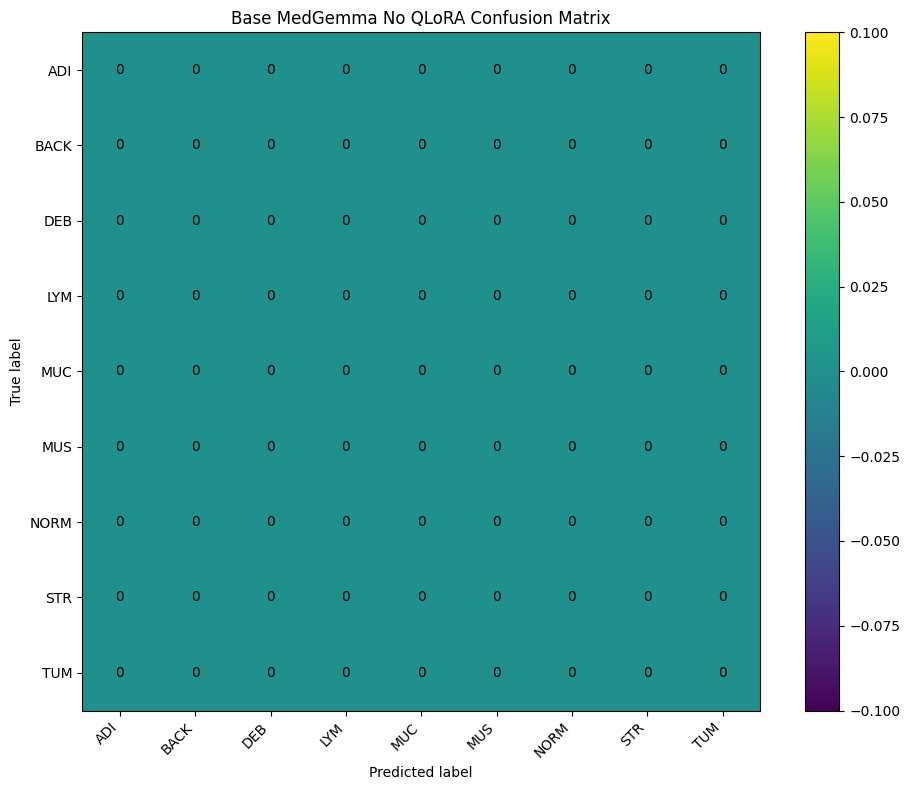

In [10]:
# 9 true-class rows x 10 predicted-class columns. The extra UNKNOWN column makes failures visible.
PRED_DISPLAY_LABELS = LABEL_NAMES + ['UNKNOWN']
pred_display_to_pos = {label: idx for idx, label in enumerate(PRED_DISPLAY_LABELS)}
true_display_to_pos = {label: idx for idx, label in enumerate(LABEL_NAMES)}

cm_with_unknown = np.zeros((len(LABEL_NAMES), len(PRED_DISPLAY_LABELS)), dtype=int)
for true_label, pred_label in zip(true_labels, pred_labels):
    pred_label = pred_label if pred_label in LABEL_NAMES else 'UNKNOWN'
    cm_with_unknown[true_display_to_pos[true_label], pred_display_to_pos[pred_label]] += 1

cm_unknown_df = pd.DataFrame(cm_with_unknown, index=LABEL_NAMES, columns=PRED_DISPLAY_LABELS)
cm_unknown_df.to_csv(RESULTS_DIR / 'base_medgemma_no_qlora_confusion_matrix_with_unknown.csv')

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(cm_with_unknown, interpolation='nearest')
fig.colorbar(im, ax=ax)

ax.set_title('Base MedGemma No QLoRA Confusion Matrix, UNKNOWN shown')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_xticks(np.arange(len(PRED_DISPLAY_LABELS)))
ax.set_yticks(np.arange(len(LABEL_NAMES)))
ax.set_xticklabels(PRED_DISPLAY_LABELS, rotation=45, ha='right')
ax.set_yticklabels(LABEL_NAMES)

for i in range(cm_with_unknown.shape[0]):
    for j in range(cm_with_unknown.shape[1]):
        ax.text(j, i, str(cm_with_unknown[i, j]), ha='center', va='center')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'base_medgemma_no_qlora_confusion_matrix_with_unknown.png', dpi=200)
plt.show()

# Also save the conventional 9x9 matrix for valid predictions only.
cm_valid_only = simple_confusion_matrix(y_true_valid, y_pred_valid, labels=list(range(len(LABEL_NAMES))))
cm_valid_only_df = pd.DataFrame(cm_valid_only, index=LABEL_NAMES, columns=LABEL_NAMES)
cm_valid_only_df.to_csv(RESULTS_DIR / 'base_medgemma_no_qlora_confusion_matrix_valid_only.csv')


## 12. Save raw predictions


In [11]:
predictions_df = pd.DataFrame({
    'image_path': image_paths,
    'true_label': true_labels,
    'predicted_label': pred_labels,
    'raw_medgemma_output': raw_outputs,
})

predictions_path = RESULTS_DIR / 'base_medgemma_no_qlora_predictions.csv'
predictions_df.to_csv(predictions_path, index=False)
print('Saved predictions to:', predictions_path)
predictions_df.head()


Saved predictions to: /kaggle/working/MedGemma_Baseline_No_QLoRA_Eval/results/base_medgemma_no_qlora_predictions.csv


,image_path,true_label,predicted_label,raw_medgemma_output
0,None,MUC,UNKNOWN,
1,None,DEB,UNKNOWN,
2,None,ADI,UNKNOWN,
3,None,MUC,UNKNOWN,
4,None,TUM,UNKNOWN,


## 13. Files created and download zip

The next cell lists the result files and creates `/kaggle/working/base_medgemma_no_qlora_results.zip` for download. Download the zip before ending the Kaggle session, or commit/save a notebook version to preserve outputs.


In [12]:
!find /kaggle/working/MedGemma_Baseline_No_QLoRA_Eval/results -maxdepth 1 -type f -printf '%f\t%k KB\n' | sort

import os
import shutil
from pathlib import Path
from IPython.display import FileLink, display

zip_base = '/kaggle/working/base_medgemma_no_qlora_results'
zip_path = shutil.make_archive(zip_base, 'zip', RESULTS_DIR)
print('Created zip:', zip_path)
print('Zip size KB:', Path(zip_path).stat().st_size // 1024)

os.chdir('/kaggle/working')
display(FileLink('base_medgemma_no_qlora_results.zip'))


base_medgemma_no_qlora_classification_report.csv	4 KB
base_medgemma_no_qlora_confusion_matrix.csv	4 KB
base_medgemma_no_qlora_confusion_matrix.png	108 KB
base_medgemma_no_qlora_metrics.json	4 KB
base_medgemma_no_qlora_predictions.csv	100 KB


## Kaggle notes

- If you see `Tesla P100 ... sm_60 is not compatible with the current PyTorch installation`, restart the Kaggle session and make sure the first install cell ran before any `import torch`.
- If the model download fails with an authorization error, confirm that `HF_TOKEN` is set in Kaggle Secrets and that the Hugging Face account behind the token has accepted the MedGemma license/access terms.
- If the dataset download fails, turn Kaggle **Internet** on or add CRC-VAL-HE-7K as a Kaggle input dataset.
- This v10 notebook runs all 7,180 images by default. It checkpoints predictions every 50 samples to `base_medgemma_no_qlora_predictions_checkpoint.csv`. If the session disconnects, rerun from the top and the evaluation cell will resume from that checkpoint if the file is still present.
